In [1]:
import os
os.environ["PYMBAR_SOLVER"] = "scipy"      

import sys, re, glob, json
import numpy as np
import pandas as pd
import scipy.ndimage
import scipy.optimize
import scipy.special
import matplotlib.pyplot as plt
import matplotlib.lines
import matplotlib.patches
import mdtraj as md
import tables as tb
import nglview as nv
import ipywidgets
import IPython.display
import pymbar, pymbar.mbar, pymbar.utils

# pymbar calls logsumexp with a use_numexpr keyword scipy does not accept
pymbar.utils.logsumexp = pymbar.mbar.logsumexp = (
    lambda a, axis=None, b=None, use_numexpr=False: scipy.special.logsumexp(a, axis=axis, b=b))

sys.path.append(os.path.join(os.environ["UPSIDE_HOME"], "py"))
import mdtraj_upside as mu

pdb_id     = "nug2b"                                                        #fme
base_dir   = os.path.join(os.pardir, "simulations", "upside", pdb_id)
refs_dir   = os.path.join(os.pardir, "references")
output_dir = os.path.join(base_dir, "outputs", "remd_077_093_linear_ri10")   #fme

# Each .run.N.up is a fixed-temperature REMD slot, not one walker: neighbouring
# frames are unrelated. load_upside_rep demultiplexes to follow one walker.
run_fns = sorted(glob.glob(os.path.join(output_dir, f"{pdb_id}.run.[0-9]*.up")),
                 key=lambda f: int(re.search(r"run\.(\d+)\.up$", f).group(1)))
traj = mu.load_upside_rep(run_fns, 0)
dssp = md.compute_dssp(traj, simplified=True)
print(traj)

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



Very Important: All distances are in nanometers for MDTraj
<mdtraj.Trajectory with 41800 frames, 332 atoms, 56 residues, without unitcells>


In [2]:
traj.superpose(traj, 0, atom_indices=traj.top.select("name CA"))

acid_sele = traj.top.select("(resname ASP or resname GLU) and name CA")
base_sele = traj.top.select("(resname LYS or resname ARG) and name CA")
dssp_colors = {"H": "#ff2255", "E": "#0099ff", "C": "#aaaaaa"}

view = nv.NGLWidget()
view.add_trajectory(traj, default_representation=False)
view.camera = "orthographic"
view.parameters = {"clipNear": -100, "clipFar": 1000, "fogNear": 0, "fogFar": 1000}
view._iplayer.close()
view.max_frame = traj.n_frames - 1

mode = ipywidgets.ToggleButtons(options=["Acid/Base", "DSSP"], description="colour:")
player = ipywidgets.Play(value=0, min=0, max=traj.n_frames - 1, interval=100)
slider = ipywidgets.IntSlider(value=0, min=0, max=traj.n_frames - 1, readout=False,
                              layout={"width": "400px"})
readout = ipywidgets.Label()

def draw(frame):
    view.clear_representations()
    if mode.value == "Acid/Base":
        view.add_cartoon(color="#888888")
        view.add_spacefill(selection=acid_sele, color="#ff0000")
        view.add_spacefill(selection=base_sele, color="#0000ff")
    else:
        for code, colour in dssp_colors.items():
            sele = [str(traj.top.residue(i).resSeq)
                    for i, ss in enumerate(dssp[frame]) if ss == code]
            if sele:
                view.add_cartoon(selection=" or ".join(sele), color=colour)

def on_frame(change):
    readout.value = "frame %d / %d" % (change["new"], traj.n_frames - 1)
    if mode.value == "DSSP":
        draw(change["new"])

ipywidgets.link((player, "value"), (slider, "value"))
ipywidgets.link((slider, "value"), (view, "frame"))
slider.observe(on_frame, names="value")
mode.observe(lambda c: draw(slider.value), names="value")
draw(0)

ipywidgets.VBox([mode, view, ipywidgets.HBox([player, slider, readout])])

---
Protection states were generated with

```
python $UPSIDE_HOME/py/get_protection_state.py \
    <protection_states>/nug2b-HDX.up  <run_dir>/nug2b.run.<i>.up \
    <protection_states>/nug2b_<i>_PS.npy --residue <...>/nug2b.resid
```

The topology must be configured with `use_heavy_atom_coverage=True` because the run
files themselves lack `hbbb_coverage` and cannot be used as their own topology.

In [3]:
PS_DIR       = os.path.join(output_dir, "protection_states")
RESIDUE_FILE = os.path.join(PS_DIR, f"{pdb_id}.resid")
SKINNER_JSON = os.path.join(refs_dir, "skinner_2014_nug2b_hdx.json")
PS_FILES     = [os.path.join(PS_DIR, f"{pdb_id}_{i}_PS.npy") for i in range(len(run_fns))]
DONOR_RESID  = np.loadtxt(RESIDUE_FILE, dtype=int)

#fme
START_FRAME  = 500       # equilibration discard (Peng: 500 for mini-proteins)
T_REF_298    = 0.85      # ff_2.1: the reduced T corresponding to 298 K
R_GAS        = 0.001987  # kcal/mol/K
UNFOLDED_CUT = 38        # N_hbond below this = unfolded; the minimum between the
                         # two modes in the next cell


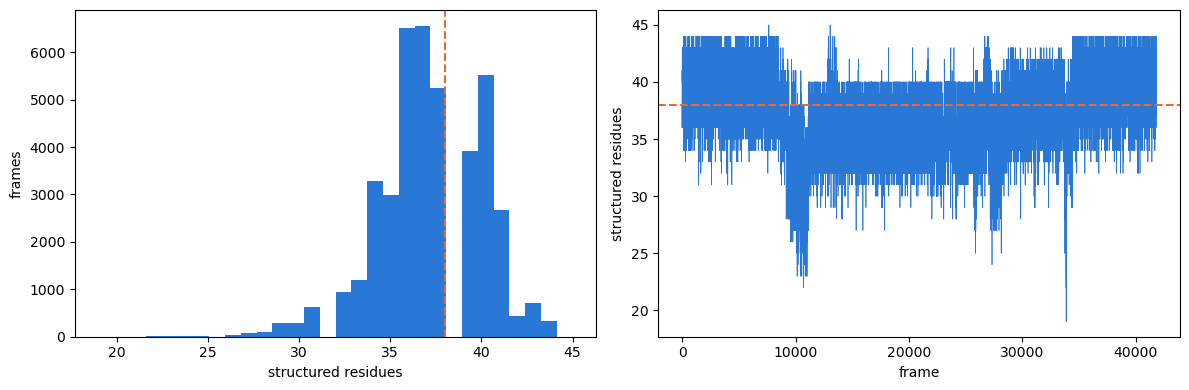

In [4]:
# UNFOLDED_CUT sits in the minimum between the two modes.
structured = ((dssp == "H") | (dssp == "E")).sum(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(structured, bins=30, color="#2a78d6")
axes[0].set_xlabel("structured residues"); axes[0].set_ylabel("frames")
axes[1].plot(structured, color="#2a78d6", lw=0.5)
axes[1].set_xlabel("frame"); axes[1].set_ylabel("structured residues")
axes[0].axvline(UNFOLDED_CUT, color="#eb6834", ls="--")
axes[1].axhline(UNFOLDED_CUT, color="#eb6834", ls="--")
plt.tight_layout(); plt.show()

In [5]:
# ---------------------------------------------------------------- experiment
skinner = json.load(open(SKINNER_JSON))
DG_GLOBAL_EXP = skinner["global"]["measurements"]["kinetics"]["delta_g"]  # kcal/mol
M_VALUE_EXP   = skinner["global"]["measurements"]["m_hx"]["value"]        # kcal/mol/M

EXP = (pd.DataFrame(skinner["residues"])
         .rename(columns={"amino_acid": "aa", "delta_g_hx": "exp", "se": "exp_se"})
         .set_index("residue")
         .sort_index())

# Experiment joins to protection-state columns through the donor residue ids, not
# a constant offset: only the ids say which column is which residue.
residues = pd.Index(DONOR_RESID + skinner["numbering"]["first_residue"], name="residue")
assert EXP.index.isin(residues).all(), "a measured residue has no NH donor column"

print("experiment: %s\n  %d NH, dG_HX %.2f-%.2f (SE %.2f-%.2f);  dG_global %.2f, m %.2f"
      % (os.path.basename(SKINNER_JSON), len(EXP), EXP["exp"].min(), EXP["exp"].max(),
         EXP["exp_se"].min(), EXP["exp_se"].max(), DG_GLOBAL_EXP, M_VALUE_EXP))

# --------------------------------------------------------------- simulation
def to_kelvin(t_red):
    return t_red * 298.0 / T_REF_298

def radius_of_gyration(fn):
    """CA radius of gyration per frame, in Angstrom (the file's own unit)."""
    with tb.open_file(fn) as t:
        xyz = np.asarray(t.root.output.pos[:, 0], dtype=float)   # N/CA/C per residue
    ca = xyz[:, 1::3]
    d  = ca - ca.mean(1, keepdims=True)
    return np.sqrt((d ** 2).sum(-1).mean(-1))

temps, energy, nhbond, radii, walkers, protect = [], [], [], [], [], []
for fn, ps_fn in zip(run_fns, PS_FILES):
    with tb.open_file(fn) as t:
        temps.append(float(t.root.output.temperature[0, 0]))
        energy.append(np.asarray(t.root.output.potential[:, 0]))
        nhbond.append(np.asarray(t.root.output.hbond[:]).sum(1))
        walkers.append(np.asarray(t.root.output.replica_index[:, 0]))
    radii.append(radius_of_gyration(fn))
    protect.append(np.load(ps_fn))

# Replicas can stop a few frames apart; one common length keeps the pooled
# ensemble rectangular, which the (rung, frame) index relies on.
keep = slice(START_FRAME, min(min(len(e) for e in energy),
                              min(len(p) for p in protect)))

# ENS -- one row per pooled sample, rep-major, which is the order MBAR assumes.
#   obs     rung temperature, potential, H-bond count, Rg, walker id
#   ps/<r>  protection state of residue r: 1 = protected, 0 = open
index = pd.MultiIndex.from_product(
    [range(len(run_fns)), np.arange(keep.start, keep.stop)], names=["rep", "frame"])
ENS = pd.concat({
    "obs": pd.DataFrame({"T":      np.repeat(temps, keep.stop - keep.start),
                         "E":      np.concatenate([e[keep] for e in energy]).astype(float),
                         "NH":     np.concatenate([h[keep] for h in nhbond]).astype(float),
                         "Rg":     np.concatenate([r[keep] for r in radii]),
                         "walker": np.concatenate([w[keep] for w in walkers])}, index=index),
    "ps":  pd.DataFrame(np.concatenate([p[keep] for p in protect]).astype(np.int8),
                        index=index, columns=residues)}, axis=1)
ENS.columns.names = ["block", "field"]
del energy, nhbond, radii, walkers, protect          # ENS owns the ensemble now

n_rep, n_res = len(run_fns), residues.size

# The ladder must span the denaturation profile or MBAR has no open states to
# reweight from. This is the precondition for everything below.
LADDER = pd.DataFrame({"T":       ENS["obs"]["T"].groupby(level="rep").first(),
                       "N_hbond": ENS["obs"]["NH"].groupby(level="rep").mean(),
                       "Rg":      ENS["obs"]["Rg"].groupby(level="rep").mean(),
                       "unf_pct": (ENS["obs"]["NH"] < UNFOLDED_CUT).groupby(level="rep").mean() * 100,
                       "prot_NH": ENS["ps"].sum(axis=1).groupby(level="rep").mean()})
LADDER.insert(1, "K", to_kelvin(LADDER["T"]))
T = LADDER["T"].to_numpy()

print("\n%d replicas, %d frames each -> %d samples, %d NH donors"
      % (n_rep, len(ENS) // n_rep, len(ENS), n_res))
IPython.display.display(LADDER.round({"T": 4, "K": 1, "N_hbond": 1,
                                      "Rg": 2, "unf_pct": 1, "prot_NH": 1}))

experiment: skinner_2014_nug2b_hdx.json
  12 NH, dG_HX 7.74-8.54 (SE 0.11-0.17);  dG_global 7.78, m 1.29

16 replicas, 41300 frames each -> 660800 samples, 55 NH donors


,T,K,N_hbond,Rg,unf_pct,prot_NH
rep,,,,,,
0,0.7700,270.0,56.8,10.27,0.0,43.0
1,0.7807,273.7,56.6,10.27,0.0,42.9
2,0.7913,277.4,56.4,10.28,0.0,42.9
3,0.8020,281.2,56.2,10.28,0.0,42.9
4,0.8127,284.9,55.9,10.29,0.0,42.9
5,0.8233,288.6,55.7,10.30,0.0,42.8
6,0.8340,292.4,55.4,10.31,0.0,42.8
7,0.8447,296.1,55.2,10.31,0.0,42.8
8,0.8553,299.9,54.9,10.32,0.0,42.8


In [6]:
# output.pos is (n_frame, 1, 3*n_res, 3): N, CA, C per residue, in Angstrom. The
# native PDB's N/CA/C selection comes out in the same order, so RMSD needs no
# remapping -- frame 0 of this native-start run gives 0.00 A.
NATIVE_PDB = os.path.join(os.pardir, "pdb", f"{pdb_id}.pdb")
RMSD_CACHE = os.path.join(output_dir, "backbone_rmsd.npy")
CHUNK      = 4000

native    = md.load(NATIVE_PDB)
ref_bb    = native.atom_slice(native.top.select("name N or name CA or name C"))
native_ca = native.atom_slice(native.top.select("name CA")).xyz[0] * 10.0
NATIVE_RG = float(np.sqrt(((native_ca - native_ca.mean(0)) ** 2).sum(-1).mean()))

if os.path.exists(RMSD_CACHE):
    rmsd_slot = np.load(RMSD_CACHE)
else:
    cols = []
    for fn in run_fns:
        with tb.open_file(fn) as t:
            pos = t.root.output.pos
            out = np.empty(pos.shape[0])
            for a in range(0, pos.shape[0], CHUNK):
                xyz = np.asarray(pos[a:a + CHUNK, 0], dtype=np.float32)
                out[a:a + CHUNK] = md.rmsd(md.Trajectory(xyz / 10.0, ref_bb.top),
                                           ref_bb, 0) * 10.0        # nm -> A
        cols.append(out)
    rmsd_slot = np.column_stack(cols)
    np.save(RMSD_CACHE, rmsd_slot)

# Slot-indexed (frame, rung), equilibration already discarded by ENS.
NH_slot   = ENS["obs"]["NH"].unstack(level="rep").to_numpy()
RG_slot   = ENS["obs"]["Rg"].unstack(level="rep").to_numpy()
WALK_slot = ENS["obs"]["walker"].unstack(level="rep").to_numpy().astype(int)
RMSD_slot = rmsd_slot[START_FRAME:START_FRAME + NH_slot.shape[0]]
n_fr, n_walker = NH_slot.shape
frames = np.arange(n_fr)

# WALK_slot[t, k] is the walker in slot k at frame t, so this inverts slot -> walker.
def by_walker(A):
    out = np.empty_like(A)
    for k in range(n_walker):
        out[frames, WALK_slot[:, k]] = A[:, k]
    return out

NH_W, RG_W, RMSD_W = by_walker(NH_slot), by_walker(RG_slot), by_walker(RMSD_slot)
UNF_W = NH_W < UNFOLDED_CUT

print("%d frames x %d walkers   native Ca Rg %.2f A   RMSD[0] %.2f A"
      % (n_fr, n_walker, NATIVE_RG, rmsd_slot[0, 0]))

41300 frames x 16 walkers   native Ca Rg 10.49 A   RMSD[0] 0.00 A


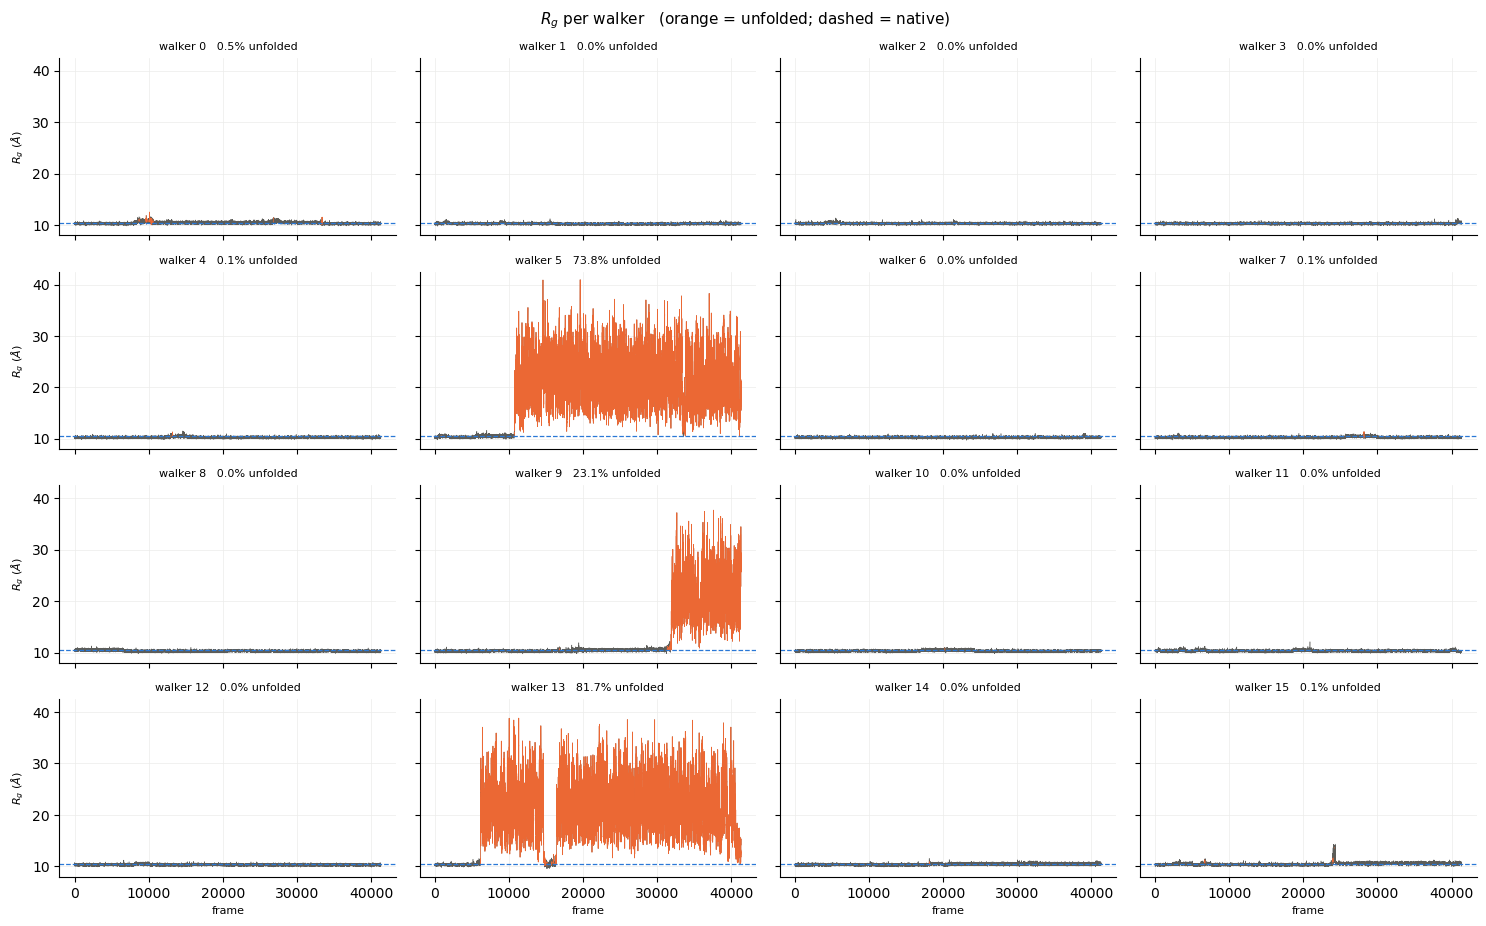

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(15, 9.4), sharex=True, sharey=True)
for w, ax in enumerate(axes.ravel()):
    rg, unf = RG_W[:, w], UNF_W[:, w]
    ax.plot(frames, rg, lw=0.35, color="#4a4a46", alpha=0.9)
    ax.plot(np.where(unf, frames, np.nan), np.where(unf, rg, np.nan),
            lw=0.5, color="#eb6834")
    ax.axhline(NATIVE_RG, color="#2a78d6", lw=0.9, ls="--")
    ax.set_title("walker %d   %.1f%% unfolded" % (w, 100 * unf.mean()), fontsize=8)
    ax.grid(True, color="#ececea", lw=0.5); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("frame", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel(r"$R_g$ ($\AA$)", fontsize=8)
fig.suptitle(r"$R_g$ per walker   (orange = unfolded; dashed = native)", fontsize=11)
plt.tight_layout(); plt.show()

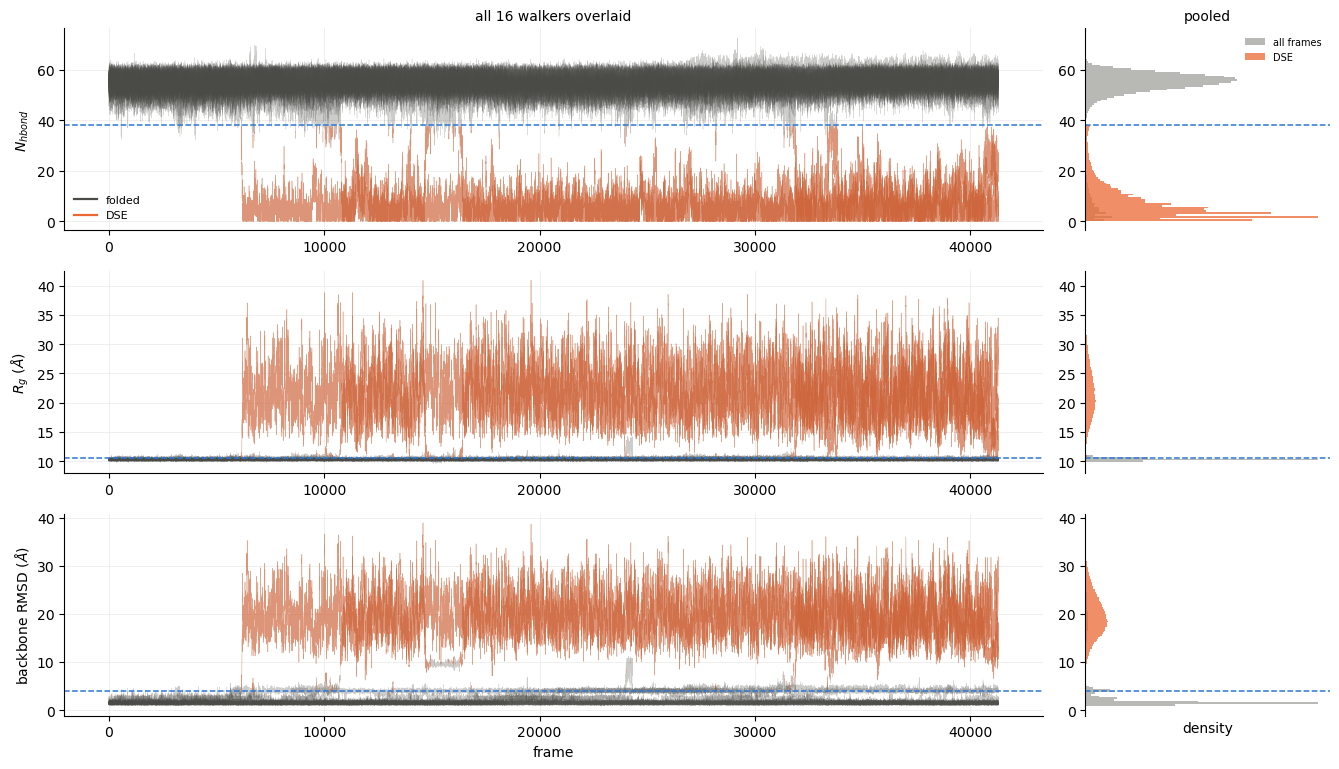

folded  N_hbond  55.0   Rg  10.3 A   protected NH  42.7
DSE     N_hbond   6.7   Rg  21.6 A   protected NH  12.4

Rg_DSE / Rg_NSE = 2.09


In [8]:
# Skinner Fig. 1A: traces with the pooled distribution beside them.
RMSD_NSE = 4.0            # his NSE criterion, alongside TM > 0.6 and >20 native H-bonds

PANELS = [(r"$N_{hbond}$",           NH_W,   UNFOLDED_CUT),
          (r"$R_g$ ($\AA$)",         RG_W,   NATIVE_RG),
          (r"backbone RMSD ($\AA$)", RMSD_W, RMSD_NSE)]

fig, axes = plt.subplots(3, 2, figsize=(13.5, 7.8),
                         gridspec_kw={"width_ratios": [4, 1]})
for row, (label, A, refline) in enumerate(PANELS):
    ax, ax_density = axes[row]

    for w in range(n_walker):
        y, unf = A[:, w], UNF_W[:, w]
        ax.plot(frames, y, lw=0.25, color="#4a4a46", alpha=0.28)
        ax.plot(np.where(unf, frames, np.nan), np.where(unf, y, np.nan),
                lw=0.3, color="#eb6834", alpha=0.55)
    ax.axhline(refline, color="#2a78d6", lw=1.1, ls="--")
    ax.set_ylabel(label)
    ax.grid(True, color="#ececea", lw=0.6); ax.set_axisbelow(True)

    bins = np.linspace(*np.percentile(A, [0.05, 99.95]), 90)
    ax_density.hist(A.ravel(), bins=bins, orientation="horizontal", density=True,
                    color="#b8b8b4", label="all frames")
    ax_density.hist(A[UNF_W], bins=bins, orientation="horizontal", density=True,
                    color="#eb6834", alpha=0.75, label="DSE")
    ax_density.axhline(refline, color="#2a78d6", lw=1.1, ls="--")
    ax_density.set_ylim(ax.get_ylim()); ax_density.set_xticks([])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("top", "right", "bottom"):
        ax_density.spines[side].set_visible(False)

axes[0, 0].legend(handles=[
    matplotlib.lines.Line2D([], [], color="#4a4a46", lw=1.6, label="folded"),
    matplotlib.lines.Line2D([], [], color="#eb6834", lw=1.6, label="DSE")],
    loc="lower left", frameon=False, fontsize=8)
axes[0, 1].legend(frameon=False, fontsize=7, loc="upper right")
axes[-1, 0].set_xlabel("frame"); axes[-1, 1].set_xlabel("density")
axes[0, 0].set_title("all %d walkers overlaid" % n_walker, fontsize=10)
axes[0, 1].set_title("pooled", fontsize=10)
plt.tight_layout(); plt.show()

# Skinner's test of the DSE: is it expanded and unstructured?
prot_NH = ENS["ps"].sum(axis=1).to_numpy()
folded_frames = (ENS["obs"]["NH"] >= UNFOLDED_CUT).to_numpy()
for name, mask_w, mask_e in (("folded", ~UNF_W, folded_frames),
                             ("DSE",     UNF_W, ~folded_frames)):
    print("%-7s N_hbond %5.1f   Rg %5.1f A   protected NH %5.1f"
          % (name, NH_W[mask_w].mean(), RG_W[mask_w].mean(), prot_NH[mask_e].mean()))
print("\nRg_DSE / Rg_NSE = %.2f" % (RG_W[UNF_W].mean() / RG_W[~UNF_W].mean()))

In [9]:
# OPTIONAL -- Peng's irreversible-unfolding truncation: keep a walker's
# native->unfolded leg and drop every frame after it re-collapses. He invokes it
# only where refolding is irreversible (Ub, L50E); every walker here refolds, and
# 18 A is calibrated on 76-residue Ub while NuG2b's separatrix is 12 A.
RG_COLLAPSE      = 18.0   # A, Peng's threshold
RG_SMOOTH        = 25     # frames in the centred rolling mean
APPLY_TRUNCATION = False  #fme

rg_walker = ENS["obs"].reset_index().pivot(index="frame", columns="walker", values="Rg")
expanded  = rg_walker.rolling(RG_SMOOTH, center=True, min_periods=1).mean() >= RG_COLLAPSE

def recollapse(unfolded):
    """First frame back below the threshold after the chain first expands."""
    up = unfolded[unfolded].index
    if up.empty:
        return np.nan
    back = unfolded[(unfolded.index > up[0]) & ~unfolded].index
    return back[0] if len(back) else np.nan

cut   = expanded.apply(recollapse)
frame = ENS.index.get_level_values("frame").to_numpy()
KEEP  = ~(frame >= ENS["obs"]["walker"].map(cut).to_numpy())   # NaN cut -> keep all

print("%d/%d walkers reach Rg >= %.0f A and re-collapse; truncation drops %d of %d"
      " frames (%.1f%%)" % (cut.notna().sum(), len(cut), RG_COLLAPSE,
                            (~KEEP).sum(), len(ENS), 100 * (~KEEP).mean()))
IPython.display.display(pd.DataFrame({"recollapse_frame": cut}).T)

if APPLY_TRUNCATION:
    ENS = ENS[KEEP]
    print("ENS truncated -- re-run from the MBAR cell")

3/16 walkers reach Rg >= 18 A and re-collapse; truncation drops 74697 of 660800 frames (11.3%)


walker,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
recollapse_frame,NaN,NaN,NaN,NaN,NaN,11314.0,NaN,NaN,NaN,32421.0,NaN,NaN,NaN,6968.0,NaN,NaN


In [10]:
# MBAR and the reweighting are numeric inner loops, so they run on plain arrays.
# These are the only views taken out of ENS; ENS stays the single source.
E        = ENS["obs"]["E"].to_numpy()
NH       = ENS["obs"]["NH"].to_numpy()
IS_OPEN  = ENS["ps"].to_numpy() == 0
N_CLOSED = ENS["ps"].sum(axis=1).to_numpy()
rung_of  = ENS.index.get_level_values("rep").to_numpy()

N_k  = ENS["obs"]["E"].groupby(level="rep").size().to_numpy()
u_kn = (1.0 / T)[:, None] * E                 # reduced potential of sample n at rung k
mbar = pymbar.MBAR(u_kn, N_k)
log_denom = scipy.special.logsumexp(mbar.f_k[:, None] - u_kn,
                                    b=N_k[:, None].astype(float), axis=0)

def weights(t_red):
    """Normalised weight of every pooled frame in the ensemble at t_red."""
    log_w = -E / t_red - log_denom
    w = np.exp(log_w - log_w.max())
    return w / w.sum()

def denatured(w, s, den, t_red):
    """Peng's denaturant layer: ddG = -s * N_closed * [den], applied on top of w."""
    u = np.exp(-s * N_CLOSED * den / t_red) * w
    return u / u.sum()

def block_se(x, n_blocks=40):
    means = [b.mean() for b in np.array_split(x, n_blocks)]
    return np.std(means, ddof=1) / np.sqrt(n_blocks)

# Reweighting back to a sampled rung must reproduce that rung's own average.
# Frames are correlated, so this uses block standard errors: a naive one
# understates the uncertainty ~10x and makes this look broken when it is fine.
z = [(weights(t) @ E - E[rung_of == k].mean()) / block_se(E[rung_of == k])
     for k, t in enumerate(T)]
print("MBAR self-consistency on <E>:  rms|z| = %.2f   max|z| = %.2f   (want O(1))"
      % (np.sqrt(np.mean(np.square(z))), np.max(np.abs(z))))


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



MBAR self-consistency on <E>:  rms|z| = 0.87   max|z| = 1.86   (want O(1))


,dH,dS,T_m_K
N_hbond,110.675,0.346,320.228
Rg,114.866,0.359,320.375


the two coordinates agree on T_m to 0.1 K
melting midpoint   T = 0.9168  (321.4 K)
stability-matched  T = 0.8518  (298.6 K)   [dG_global = 7.78, 23 K below T_m]


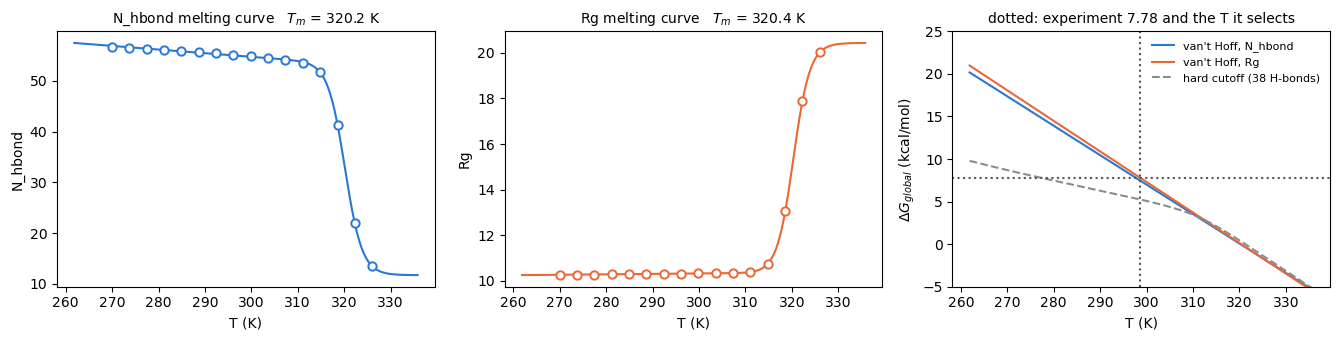

In [11]:
# Peng (SI Fig. S8, Table S1): "the free energy is obtained from the simulated
# melting curve of either the fraction of H-bonds or the Rg using dG(T) = dH - T*dS",
# with dH and dS from a two-state fit. No threshold is involved 
GUESS = {"N_hbond": (76.0, -0.07, 12.0, 110.0, 0.35),
         "Rg":      (9.8, 0.002, 20.0, 110.0, 0.35)}

def to_kelvin(t_red):
    return t_red * 298.0 / T_REF_298

def two_state(TK, folded, slope, unfolded, dH, dS):
    """Observable vs T for N <-> U with a sloped native baseline."""
    K = np.exp(-(dH - TK * dS) / (R_GAS * TK))        # K = [U]/[N]
    return (folded + slope * TK + unfolded * K) / (1.0 + K)

def fit_melting(curve, guess):
    p, cov = scipy.optimize.curve_fit(two_state, LADDER["K"], curve, p0=guess, maxfev=20000)
    return p, np.sqrt(np.diag(cov))

W_T = [weights(t) for t in T]           # reweighted to each rung, reused below

def dG_global(t_red, s, den):
    """Peng's dG_global at t_red, with his denaturant layer applied first."""
    curve = [denatured(w, s, den, t) @ NH for t, w in zip(T, W_T)]
    dH, dS = fit_melting(curve, GUESS["N_hbond"])[0][3:]
    return dH - to_kelvin(t_red) * dS

dH, dS     = fit_melting([w @ NH for w in W_T], GUESS["N_hbond"])[0][3:]
T_MELT     = dH / dS * T_REF_298 / 298
T_ANALYSIS = (dH - DG_GLOBAL_EXP) / dS * T_REF_298 / 298

FITS = pd.DataFrame({coord: fit_melting(LADDER[coord], GUESS[coord])[0][3:]
                     for coord in GUESS}, index=["dH", "dS"]).T
FITS["T_m_K"] = FITS["dH"] / FITS["dS"]
IPython.display.display(FITS.round(3))
print("the two coordinates agree on T_m to %.1f K"
      % abs(FITS["T_m_K"].diff().iloc[-1]))
print("melting midpoint   T = %.4f  (%.1f K)" % (T_MELT, to_kelvin(T_MELT)))
print("stability-matched  T = %.4f  (%.1f K)   [dG_global = %.2f, %.0f K below T_m]"
      % (T_ANALYSIS, to_kelvin(T_ANALYSIS), DG_GLOBAL_EXP,
         to_kelvin(T_MELT) - to_kelvin(T_ANALYSIS)))

def dG_global_cut(t_red):
    """The hard-cutoff alternative, for the comparison in the third panel."""
    p_unf = weights(t_red)[NH < UNFOLDED_CUT].sum()
    return R_GAS * to_kelvin(t_red) * np.log((1.0 - p_unf) / p_unf)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))
t_fine = np.linspace(T.min() * 0.97, T.max() * 1.03, 300)
for ax, coord, colour in zip(axes, GUESS, ["#2a78d6", "#eb6834"]):
    p = fit_melting(LADDER[coord], GUESS[coord])[0]
    ax.plot(to_kelvin(t_fine), two_state(to_kelvin(t_fine), *p), "-", c=colour)
    ax.plot(LADDER["K"], LADDER[coord], "o", c=colour, mfc="white", mew=1.4)
    ax.set_xlabel("T (K)"); ax.set_ylabel(coord)
    ax.set_title("%s melting curve   $T_m$ = %.1f K"
                 % (coord, FITS.at[coord, "T_m_K"]), fontsize=10)

# The hard cut agrees at T_m but reads the stability too low below it: its
# unfolded bin also collects partially-unfolded conformations, whose population
# falls far slower than the true two-state one. It would have picked T = 0.79.
ax = axes[2]
for coord, colour in zip(GUESS, ["#2a78d6", "#eb6834"]):
    ax.plot(to_kelvin(t_fine),
            FITS.at[coord, "dH"] - to_kelvin(t_fine) * FITS.at[coord, "dS"],
            "-", c=colour, label="van't Hoff, %s" % coord)
ax.plot(to_kelvin(t_fine), [dG_global_cut(t) for t in t_fine], "--", c="#8c8c8c",
        label="hard cutoff (%d H-bonds)" % UNFOLDED_CUT)
ax.axhline(DG_GLOBAL_EXP, ls=":", c="#555"); ax.axvline(to_kelvin(T_ANALYSIS), ls=":", c="#555")
ax.set_ylim(-5, 25); ax.set_xlabel("T (K)"); ax.set_ylabel(r"$\Delta G_{global}$ (kcal/mol)")
ax.set_title("dotted: experiment %.2f and the T it selects" % DG_GLOBAL_EXP, fontsize=10)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

In [12]:
# Peng's FES coordinates: PCA of the Ca-Ca contact matrix, contact = d < 10 A.
PCA_STRIDE  = 20        #fme  frames kept for the contact matrix (memory, not accuracy)
CONTACT_CUT = 10.0
MIN_SEP     = 3         # skip |i-j| < 3: trivially in contact, no information
PCA_CACHE   = os.path.join(output_dir, "contact_pca.npz")

n_per   = len(ENS) // n_rep
sub_idx = np.concatenate([k * n_per + np.arange(0, n_per, PCA_STRIDE)
                          for k in range(n_rep)])

if os.path.exists(PCA_CACHE):
    cached = np.load(PCA_CACHE)
    PC, var_frac = cached["PC"], cached["var_frac"]
else:
    with tb.open_file(run_fns[0]) as t:
        n_ca = t.root.output.pos.shape[2] // 3
    ii, jj = np.triu_indices(n_ca, k=MIN_SEP)
    blocks = []
    for fn in run_fns:
        with tb.open_file(fn) as t:
            pos = t.root.output.pos
            wanted = np.arange(START_FRAME, START_FRAME + n_per, PCA_STRIDE)
            for a in range(0, wanted.size, 500):
                sel = wanted[a:a + 500]
                ca  = np.asarray(pos[sel[0]:sel[-1] + 1:PCA_STRIDE, 0, 1::3],
                                 dtype=np.float32)
                d2  = ((ca[:, :, None, :] - ca[:, None, :, :]) ** 2).sum(-1)
                blocks.append(d2[:, ii, jj] < CONTACT_CUT ** 2)
    contacts = np.concatenate(blocks).astype(np.float32)
    assert contacts.shape[0] == sub_idx.size

    # Covariance route rather than SVD: 1431 features is a small matrix, the frame
    # count is not. Contacts that never change carry no variance.
    centred = contacts[:, contacts.var(0) > 1e-6]
    centred -= centred.mean(0)
    evals, evecs = np.linalg.eigh((centred.T @ centred) / (centred.shape[0] - 1))
    order = np.argsort(evals)[::-1]
    PC = centred @ evecs[:, order[:2]]
    # PCA signs are arbitrary; pin PC1 to increase with contact count so the
    # native well lands on the right in every run.
    if np.corrcoef(PC[:, 0], contacts.sum(1))[0, 1] < 0:
        PC[:, 0] *= -1.0
    var_frac = evals[order[:2]] / evals.sum()
    np.savez(PCA_CACHE, PC=PC, var_frac=var_frac)
    del contacts, centred, blocks

NH_sub, RG_sub = NH[sub_idx], ENS["obs"]["Rg"].to_numpy()[sub_idx]
FOLD_sub = NH_sub >= UNFOLDED_CUT
print("%d frames (stride %d);  PC1 %.1f%%, PC2 %.1f%% of contact-matrix variance"
      % (sub_idx.size, PCA_STRIDE, 100 * var_frac[0], 100 * var_frac[1]))

33040 frames (stride 20);  PC1 27.2%, PC2 8.7% of contact-matrix variance


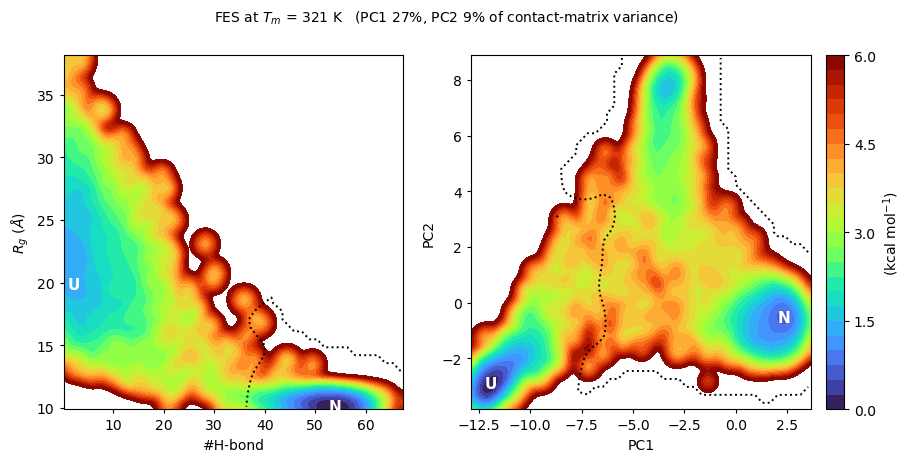

In [13]:
# Peng Fig. 4: smooth filled contours, rainbow 0-6 kcal/mol, white outside the
# sampled region, dotted NSE boundary, wells labelled N and U.
FES_CMAP   = "turbo"    # "jet" is the literal paper match; turbo reads the same
FES_BINS   = 140
FES_SMOOTH = 2.6        # bins; below ~2 the sparse rim breaks into speckle
NSE_BINS, NSE_SMOOTH = 45, 1.6
F_MAX, N_LEV = 6.0, 25

AXES   = [(NH_sub, RG_sub, "#H-bond", r"$R_g$ ($\AA$)"),
          (PC[:, 0], PC[:, 1], "PC1", "PC2")]
LEVELS = np.linspace(0.0, F_MAX, N_LEV)
RT     = R_GAS * to_kelvin(T_MELT)
w_fes  = weights(T_MELT)[sub_idx]
w_fes /= w_fes.sum()

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6))
for ax, (X, Y, xlabel, ylabel) in zip(axes, AXES):
    # Smooth the density, then take -RT ln. Smoothing the free energy instead
    # averages across the log and flattens the wells.
    H, xe, ye = np.histogram2d(X, Y, bins=FES_BINS, weights=w_fes)
    P = scipy.ndimage.gaussian_filter(H, FES_SMOOTH)
    P /= P.sum()
    with np.errstate(divide="ignore"):
        F = -RT * np.log(P)
    F -= F[np.isfinite(F)].min()
    xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
    # extend="neither" leaves everything above F_MAX unfilled, so unsampled
    # regions come out white as in the paper.
    contours = ax.contourf(xc, yc, F.T, levels=LEVELS, cmap=FES_CMAP, extend="neither")
    contours.set_edgecolor("face")            # no hairline seams between levels

    # NSE boundary on its own coarser grid: at FES resolution the folded fraction
    # is noisy wherever the density is thin and the 0.5 isoline breaks into islands.
    nb = (np.linspace(xe[0], xe[-1], NSE_BINS + 1),
          np.linspace(ye[0], ye[-1], NSE_BINS + 1))
    smooth = lambda weight: scipy.ndimage.gaussian_filter(
        np.histogram2d(X, Y, bins=nb, weights=weight)[0], NSE_SMOOTH)
    total, folded = smooth(w_fes), smooth(w_fes * FOLD_sub)
    frac = folded / np.where(total > total.max() * 1e-4, total, np.inf)
    xn, yn = 0.5 * (nb[0][:-1] + nb[0][1:]), 0.5 * (nb[1][:-1] + nb[1][1:])
    ax.contour(xn, yn, frac.T, levels=[0.5], colors="k", linestyles=":", linewidths=1.4)

    # N and U: deepest point of the FES on each side of that boundary.
    frac_fes = scipy.ndimage.zoom(frac, np.array(F.shape) / np.array(frac.shape), order=1)
    for label, side in (("N", frac_fes > 0.5), ("U", frac_fes <= 0.5)):
        i, j = np.unravel_index(np.argmin(np.where(side, F, np.inf)), F.shape)
        ax.annotate(label, (xc[i], yc[j]), color="white", fontsize=11,
                    fontweight="bold", ha="center", va="center")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.tick_params(direction="out", length=3)

cb = fig.colorbar(contours, ax=axes, fraction=0.035, pad=0.02,
                  ticks=np.linspace(0, F_MAX, 5))
cb.set_label(r"(kcal mol$^{-1}$)")
fig.suptitle("FES at $T_m$ = %.0f K   (PC1 %.0f%%, PC2 %.0f%% of contact-matrix"
             " variance)" % (to_kelvin(T_MELT), 100 * var_frac[0], 100 * var_frac[1]),
             fontsize=10)
plt.show()

In [14]:
def hdx(w):
    """Per-residue dG_HX at T_ANALYSIS under weights w.
    p_open is summed directly over open frames: computing it as 1 - <PS> is
    catastrophic cancellation for protected residues, and the roundoff lands
    *above* the experimental answer, so it looks like success."""
    RT = R_GAS * to_kelvin(T_ANALYSIS)
    p_open, ess_open = np.array([[w[o].sum(), w[o].sum() ** 2 / (w[o] ** 2).sum()]
                                 for o in IS_OPEN.T]).T
    return pd.DataFrame({"dg": RT * np.log1p(-p_open) - RT * np.log(p_open),
                         "p_open": p_open, "ess_open": ess_open}, index=residues)

w_analysis = weights(T_ANALYSIS)
HDX = hdx(w_analysis)
HDX["n_open"]   = IS_OPEN.sum(0)
HDX["resolved"] = (HDX["n_open"] >= 5) & (HDX["ess_open"] >= 5)
HDX = HDX.join(EXP)

w_unf = w_analysis[NH < UNFOLDED_CUT]
print("T = %.4f   RT = %.4f   ESS = %.0f   ESS_unfolded = %.1f"
      % (T_ANALYSIS, R_GAS * to_kelvin(T_ANALYSIS), 1.0 / (w_analysis ** 2).sum(),
         w_unf.sum() ** 2 / (w_unf ** 2).sum()))
print("%d/%d residues resolved" % (HDX["resolved"].sum(), n_res))

T = 0.8518   RT = 0.5934   ESS = 481839   ESS_unfolded = 360.0
55/55 residues resolved


In [15]:
# Exchange route by denaturant sensitivity (Peng Fig. 1, Fig. S27): global,
# subglobal and local openings have large, medium and near-zero m-values. He
# decomposes m_total = m_closed - m_open so that m_total = k * (H-bonds broken on
# opening), which makes "small m-values represent the local breaking of 1-2
# H-bonds" a literal reading. dN_HB is what the classification uses.
PENG_LOCAL_MAX_HB = 2      # "the local breaking of 1-2 H-bonds"
PENG_GLOBAL_FRAC  = 0.8    # dN_HB this close to the global value = a global exchanger
GAP_TOL           = 0.25   # kcal/mol from the global line = a global exchanger
DEN = np.r_[np.arange(0.0, 4.01, 0.25), [5.0, 6.0, 8.0, 10.0, 12.0]]

# s from the experimental m_global, exactly as Table S4 does it.
s_grid = np.linspace(0.01, 0.30, 30)
m_grid = [dG_global(T_ANALYSIS, s, 0.0) - dG_global(T_ANALYSIS, s, 1.0) for s in s_grid]
s_cal  = np.interp(M_VALUE_EXP, m_grid, s_grid)
K_HB   = R_GAS * to_kelvin(T_ANALYSIS) * s_cal / T_ANALYSIS   # kcal/mol/M per H-bond

def m_values(w):
    """Peng's m_total = m_closed - m_open, both referenced to the whole ensemble."""
    n_all  = w @ N_CLOSED
    p_open = np.array([w[o].sum() for o in IS_OPEN.T])
    s_open = np.array([w[o] @ N_CLOSED[o] for o in IS_OPEN.T])
    m_closed = K_HB * ((n_all - s_open) / (1.0 - p_open) - n_all)
    m_open   = K_HB * (s_open / p_open - n_all)
    return pd.DataFrame({"m_closed": m_closed, "m_open": m_open,
                         "m_total": m_closed - m_open}, index=residues)

CURVES = pd.DataFrame({d: hdx(denatured(w_analysis, s_cal, d, T_ANALYSIS))["dg"]
                       for d in DEN})
GLOBAL_LINE = pd.Series({d: dG_global(T_ANALYSIS, s_cal, d) for d in DEN})

HDX = HDX.join(m_values(w_analysis))
HDX["dN_HB"] = HDX["m_total"] / K_HB
dN_global    = (GLOBAL_LINE[0.0] - GLOBAL_LINE[1.0]) / K_HB
HDX["route"] = np.where(HDX["dN_HB"] >= PENG_GLOBAL_FRAC * dN_global, "global",
                        np.where(HDX["dN_HB"] <= PENG_LOCAL_MAX_HB, "local", "subglobal"))

# Peng marks as global those residues that first become global exchangers as
# denaturant rises -- i.e. where dG_HX meets the global line, since a residue with
# any cheaper channel sits below it.
gap = CURVES.rsub(GLOBAL_LINE, axis=1)
HDX["den_global"] = [np.interp(-GAP_TOL, -row, DEN) for row in gap.to_numpy()]
MEAS = HDX[HDX["exp"].notna()]

print("s = %.3f from experimental m_global = %.2f   (Peng Table S4: 0.038-0.068)"
      % (s_cal, M_VALUE_EXP))
print("k = %.3f kcal/mol/M per H-bond  ->  global unfolding = %.1f H-bonds"
      % (K_HB, dN_global))
IPython.display.display(MEAS[["aa", "exp", "dg", "m_total", "dN_HB", "den_global",
                              "ess_open", "resolved", "route"]]
                        .round({"exp": 2, "dg": 2, "m_total": 3, "dN_HB": 1,
                                "den_global": 1, "ess_open": 0}))

# Resolved residues only: an unconverged value is not a measurement.
SPLIT = (MEAS[MEAS["resolved"]].assign(err=lambda f: f["dg"] - f["exp"])
         .groupby("route")["err"]
         .agg(n="size", RMSE=lambda e: np.sqrt((e ** 2).mean()), bias="mean"))
err = MEAS["dg"] - MEAS["exp"]
SPLIT.loc["all"] = [len(err), np.sqrt((err ** 2).mean()), err.mean()]
IPython.display.display(SPLIT.round(2))

s = 0.073 from experimental m_global = 1.29   (Peng Table S4: 0.038-0.068)
k = 0.051 kcal/mol/M per H-bond  ->  global unfolding = 25.5 H-bonds


,aa,exp,dg,m_total,dN_HB,den_global,ess_open,resolved,route
residue,,,,,,,,,
3,Y,8.08,1.70,-0.024,-0.5,4.6,25795.0,True,local
4,K,8.54,1.66,-0.021,-0.4,4.6,27702.0,True,local
5,L,8.31,5.29,0.248,4.9,2.2,98.0,True,subglobal
6,V,8.09,3.95,0.163,3.2,3.2,816.0,True,subglobal
7,I,7.84,5.21,0.131,2.6,2.1,108.0,True,subglobal
16,Y,7.85,5.13,0.138,2.7,2.1,105.0,True,subglobal
18,T,7.85,3.08,0.069,1.4,3.6,2820.0,True,local
26,A,8.45,2.06,0.075,1.5,4.5,14772.0,True,local
27,E,7.74,2.09,0.078,1.5,4.6,14278.0,True,local


,n,RMSE,bias
route,,,
local,6.0,6.11,-6.07
subglobal,6.0,2.77,-2.63
all,12.0,4.74,-4.35


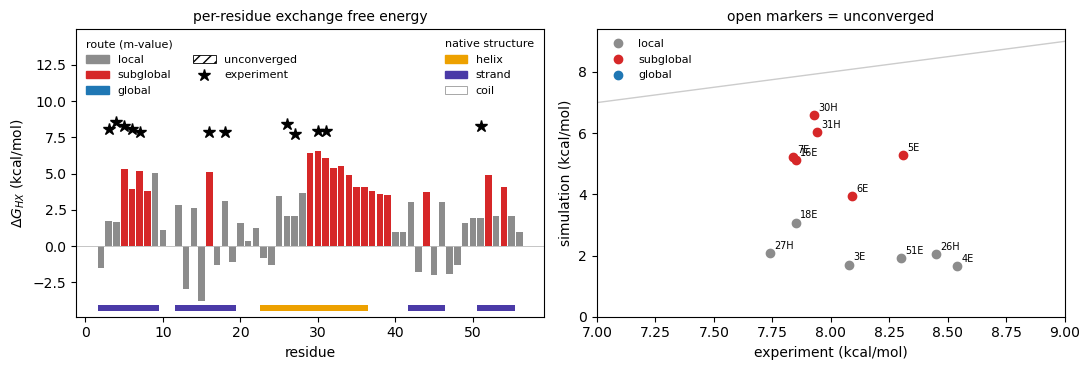

In [16]:
# Native secondary structure: the modal DSSP state over folded frames only.
# Averaging over unfolded frames would wash the assignment out to coil.
folded = ((dssp == "H") | (dssp == "E")).sum(1) >= UNFOLDED_CUT
ss = pd.Series(np.array(list("HEC"))[np.stack([(dssp[folded] == c).sum(0)
                                               for c in "HEC"]).argmax(0)],
               index=np.arange(dssp.shape[1]) + skinner["numbering"]["first_residue"],
               name="ss").reindex(residues)

# Peng Fig. S27 colours, the grey lightened to clear the separation floor.
ROUTE_COLOUR = {"local": "#8c8c8c", "subglobal": "#d62728", "global": "#1f77b4"}
SS_COLOUR    = {"H": "#eda100", "E": "#4a3aa7"}          # coil is left unpainted
SS_NAME      = {"H": "helix", "E": "strand"}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
ax.bar(HDX.index, HDX["dg"], width=0.85, color=HDX["route"].map(ROUTE_COLOUR))
ax.bar(HDX.index[~HDX["resolved"]], HDX["dg"][~HDX["resolved"]], width=0.85,
       color="none", edgecolor="k", hatch="///", lw=0.6)
ax.plot(MEAS.index, MEAS["exp"], "k*", ms=9, ls="none")
ax.axhline(0, color="#bbbbbb", lw=0.6)

# Secondary-structure track in a band below the bars' baseline.
band = 0.045 * (HDX["dg"].max() - min(0.0, HDX["dg"].min()))
base = min(0.0, HDX["dg"].min()) - 1.5 * band
for _, run in ss.groupby((ss != ss.shift()).cumsum()):
    if run.iloc[0] in SS_COLOUR:
        ax.add_patch(matplotlib.patches.Rectangle(
            (run.index[0] - 0.43, base), len(run) - 0.14, band, lw=0,
            color=SS_COLOUR[run.iloc[0]]))
ax.set_ylim(base - 0.8 * band, max(HDX["dg"].max(), MEAS["exp"].max()) * 1.75)
ax.set_xlabel("residue"); ax.set_ylabel(r"$\Delta G_{HX}$ (kcal/mol)")
ax.set_title("per-residue exchange free energy", fontsize=10)

routes = ax.legend(handles=[matplotlib.patches.Patch(color=c, label=r)
                            for r, c in ROUTE_COLOUR.items()]
                   + [matplotlib.patches.Patch(facecolor="none", edgecolor="k",
                                               hatch="///", lw=0.6, label="unconverged"),
                      matplotlib.lines.Line2D([], [], color="k", marker="*", ls="none",
                                              ms=9, label="experiment")],
                   loc="upper left", ncol=2, frameon=False, fontsize=8,
                   title="route (m-value)", title_fontsize=8, alignment="left")
ax.add_artist(routes)                       # else the next legend replaces it
ax.legend(handles=[matplotlib.patches.Patch(color=c, label=SS_NAME[k])
                   for k, c in SS_COLOUR.items()]
          + [matplotlib.patches.Patch(facecolor="none", edgecolor="#999999", lw=0.6,
                                      label="coil")],
          loc="upper right", frameon=False, fontsize=8,
          title="native structure", title_fontsize=8, alignment="left")

ax = axes[1]
for route, colour in ROUTE_COLOUR.items():
    grp = MEAS[MEAS["route"] == route]
    ax.plot(grp.loc[grp["resolved"], "exp"], grp.loc[grp["resolved"], "dg"],
            "o", c=colour, label=route)
    ax.plot(grp.loc[~grp["resolved"], "exp"], grp.loc[~grp["resolved"], "dg"],
            "o", mfc="none", mec=colour)
limit = [0, max(MEAS["dg"].max(), MEAS["exp"].max()) * 1.1]
ax.plot(limit, limit, "-", c="#ccc", lw=1)
for r, row in MEAS.iterrows():
    ax.annotate("%d%s" % (r, ss[r]), (row["exp"], row["dg"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlim(7.0, 9.0); ax.set_ylim(limit)
ax.set_xlabel("experiment (kcal/mol)"); ax.set_ylabel("simulation (kcal/mol)")
ax.set_title("open markers = unconverged", fontsize=10)
ax.legend(frameon=False, fontsize=8)

plt.tight_layout(); plt.show()

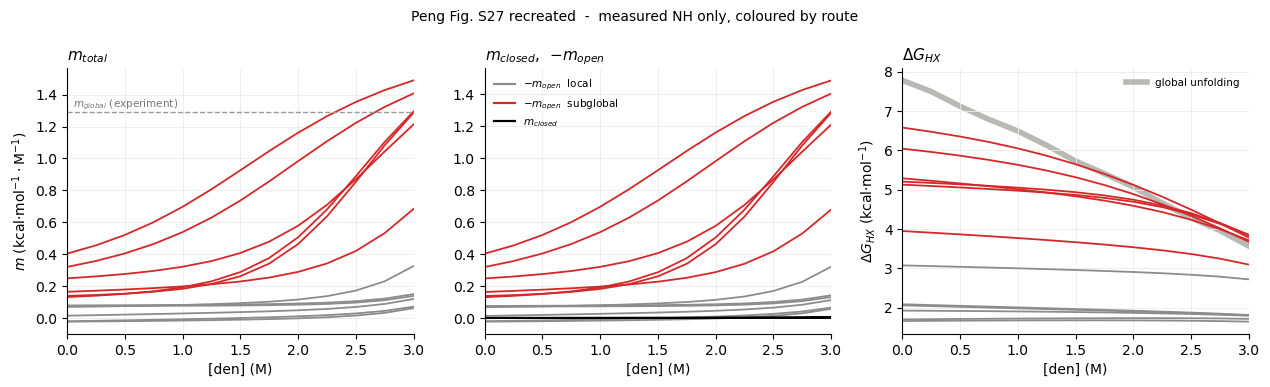

In [17]:
# Peng Fig. S27
S27_MAX = 3.0    # plot window; the global line reaches zero near 6 M
den_x = np.array([d for d in DEN if d <= S27_MAX])
MDEN  = {d: m_values(denatured(w_analysis, s_cal, d, T_ANALYSIS)) for d in den_x}
route_colour = [ROUTE_COLOUR[HDX.at[r, "route"]] for r in MEAS.index]

fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.9))

ax = axes[0]
for r, colour in zip(MEAS.index, route_colour):
    ax.plot(den_x, [MDEN[d].at[r, "m_total"] for d in den_x], "-", c=colour, lw=1.3)
ax.axhline(M_VALUE_EXP, ls="--", c="#999999", lw=1)
ax.annotate("$m_{global}$ (experiment)", (0.05, M_VALUE_EXP), ha="left", va="bottom",
            fontsize=7.5, color="#777777")
ax.set_ylabel(r"$m$ (kcal$\cdot$mol$^{-1}\cdot$M$^{-1}$)")
ax.set_title(r"$m_{total}$", fontsize=11, loc="left")

ax = axes[1]
for r, colour in zip(MEAS.index, route_colour):
    ax.plot(den_x, [-MDEN[d].at[r, "m_open"] for d in den_x], "-", c=colour, lw=1.3)
for r in MEAS.index:                     
    ax.plot(den_x, [MDEN[d].at[r, "m_closed"] for d in den_x], "-", c="k", lw=1.1)
ax.set_title(r"$m_{closed}$,  $-m_{open}$", fontsize=11, loc="left")
ax.legend(handles=[matplotlib.lines.Line2D([], [], color=c, lw=1.6,
                                           label=r"$-m_{open}$  %s" % k)
                   for k, c in ROUTE_COLOUR.items() if (HDX["route"] == k).any()]
                  + [matplotlib.lines.Line2D([], [], color="k", lw=1.6,
                                             label=r"$m_{closed}$")],
          loc="upper left", frameon=False, fontsize=7.5)

ax = axes[2]
ax.plot(den_x, GLOBAL_LINE.loc[den_x].to_numpy(), "-", c="#b8b8b4", lw=4, zorder=0,
        label="global unfolding")
for r, colour in zip(MEAS.index, route_colour):
    ax.plot(den_x, CURVES.loc[r, den_x].to_numpy(), "-", c=colour, lw=1.3)
ax.set_ylabel(r"$\Delta G_{HX}$ (kcal$\cdot$mol$^{-1}$)")
ax.set_title(r"$\Delta G_{HX}$", fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=7.5, loc="upper right")

for ax in axes:
    ax.set_xlabel("[den] (M)")
    ax.set_xlim(0, S27_MAX)
    ax.grid(True, color="#ececea", lw=0.6); ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.suptitle("Peng Fig. S27 recreated  -  measured NH only, coloured by route",
             fontsize=10)
plt.tight_layout(); plt.show()

m_closed = np.array([[MDEN[d].at[r, "m_closed"] for d in den_x] for r in MEAS.index])